In [ ]:

# PROJECT 1 - INDUSTRIAL MACHINE INTELLIGENCE


!pip -q install pandas numpy matplotlib seaborn plotly scikit-learn joblib gradio fastapi uvicorn requests

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    IsolationForest
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.inspection import permutation_importance

import joblib

print("✅ Libraries installed successfully!")

✅ Libraries installed successfully!


In [ ]:

# DOWNLOAD NASA C-MAPSS FD001

import os
import requests

os.makedirs("/content/cmapss", exist_ok=True)

files = {
    "train_FD001.txt":
        "https://raw.githubusercontent.com/PunVas/nasa-c-mapss/main/train_FD001.txt",

    "test_FD001.txt":
        "https://raw.githubusercontent.com/PunVas/nasa-c-mapss/main/test_FD001.txt",

    "RUL_FD001.txt":
        "https://raw.githubusercontent.com/PunVas/nasa-c-mapss/main/RUL_FD001.txt"
}

for filename, url in files.items():

    path = f"/content/cmapss/{filename}"

    if not os.path.exists(path):

        response = requests.get(url, timeout=60)
        response.raise_for_status()

        with open(path, "wb") as f:
            f.write(response.content)

        print(f"✅ Downloaded: {filename}")

    else:
        print(f"✔ Already exists: {filename}")

print("\n🎯 Dataset setup completed!")

✅ Downloaded: train_FD001.txt
✅ Downloaded: test_FD001.txt
✅ Downloaded: RUL_FD001.txt

🎯 Dataset setup completed!


In [ ]:

# MODULE 1 - DATA ENGINEERING & PREPROCESSING

column_names = (
    ["engine_id", "cycle",
     "op_setting_1", "op_setting_2", "op_setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

train_df = pd.read_csv(
    "/content/cmapss/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=column_names
)

test_df = pd.read_csv(
    "/content/cmapss/test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=column_names
)

rul_values = pd.read_csv(
    "/content/cmapss/RUL_FD001.txt",
    header=None,
    names=["RUL"]
)

# Remove constant sensors
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]

constant_sensors = [
    col for col in sensor_cols
    if train_df[col].nunique() <= 1
]

train_df.drop(columns=constant_sensors, inplace=True)
test_df.drop(columns=constant_sensors, inplace=True)

# Calculate RUL for every training row
max_cycles = train_df.groupby("engine_id")["cycle"].transform("max")

train_df["RUL"] = max_cycles - train_df["cycle"]

# RUL cap
train_df["RUL"] = train_df["RUL"].clip(upper=125)

print("========== DATASET INFORMATION ==========")
print("Training shape :", train_df.shape)
print("Testing shape  :", test_df.shape)
print("Engines        :", train_df["engine_id"].nunique())
print("Removed sensors:", constant_sensors)

print("\nFirst 5 rows:")
display(train_df.head())

========== DATASET INFORMATION ==========
Training shape : (20631, 21)
Testing shape  : (13096, 20)
Engines        : 100
Removed sensors: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

First 5 rows:


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,21.61,554.36,...,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,21.61,553.75,...,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,21.61,554.26,...,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,21.61,554.45,...,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,21.61,554.00,...,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,125


========== SENSOR STATISTICS ==========


,count,mean,std,min,25%,50%,75%,max
sensor_2,20631.0,642.680934,0.500053,641.21,642.325,642.64,643.000,644.53
sensor_3,20631.0,1590.523119,6.131150,1571.04,1586.260,1590.10,1594.380,1616.91
sensor_4,20631.0,1408.933782,9.000605,1382.25,1402.360,1408.04,1414.555,1441.49
sensor_6,20631.0,21.609803,0.001389,21.60,21.610,21.61,21.610,21.61
sensor_7,20631.0,553.367711,0.885092,549.85,552.810,553.44,554.010,556.06
sensor_8,20631.0,2388.096652,0.070985,2387.90,2388.050,2388.09,2388.140,2388.56
sensor_9,20631.0,9065.242941,22.082880,9021.73,9053.100,9060.66,9069.420,9244.59
sensor_11,20631.0,47.541168,0.267087,46.85,47.350,47.51,47.700,48.53
sensor_12,20631.0,521.413470,0.737553,518.69,520.960,521.48,521.950,523.38
sensor_13,20631.0,2388.096152,0.071919,2387.88,2388.040,2388.09,2388.140,2388.56



Top variable sensors:
['sensor_9', 'sensor_14', 'sensor_4', 'sensor_3', 'sensor_17', 'sensor_7']


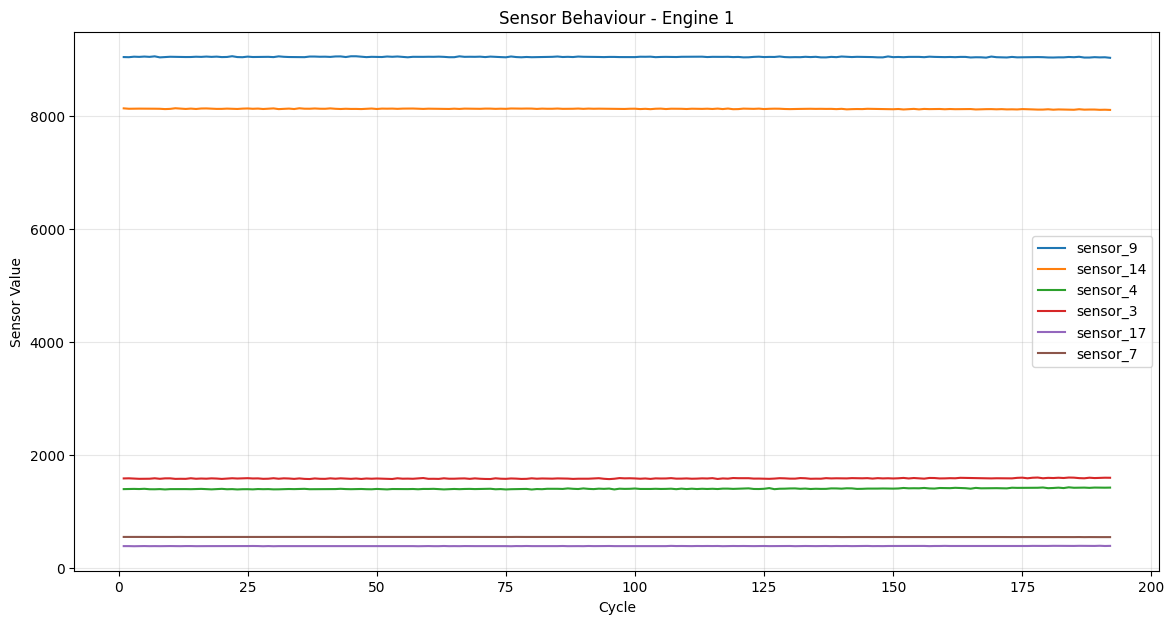

In [ ]:

# MODULE 2 - SENSOR DATA ANALYSIS

available_sensors = [
    c for c in train_df.columns
    if c.startswith("sensor_")
]

# Sensor statistics
sensor_stats = train_df[available_sensors].describe().T

print("========== SENSOR STATISTICS ==========")
display(sensor_stats.head(10))

# Select sensors with highest variation
sensor_variance = train_df[available_sensors].var().sort_values(
    ascending=False
)

top_sensors = sensor_variance.head(6).index.tolist()

print("\nTop variable sensors:")
print(top_sensors)

# Plot
plt.figure(figsize=(14, 7))

for sensor in top_sensors:
    plt.plot(
        train_df[train_df.engine_id == 1]["cycle"],
        train_df[train_df.engine_id == 1][sensor],
        label=sensor
    )

plt.title("Sensor Behaviour - Engine 1")
plt.xlabel("Cycle")
plt.ylabel("Sensor Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

========== FAILURE PREDICTION ==========
Accuracy: 0.9639

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98      3507
Failure Risk       0.90      0.86      0.88       620

    accuracy                           0.96      4127
   macro avg       0.94      0.92      0.93      4127
weighted avg       0.96      0.96      0.96      4127



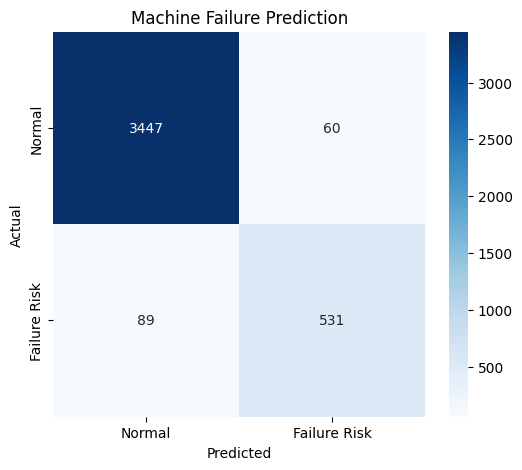

In [ ]:

# MODULE 3 - MACHINE FAILURE PREDICTION

features = available_sensors

X = train_df[features].copy()

y_failure = (train_df["RUL"] <= 30).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_failure,
    test_size=0.20,
    random_state=42,
    stratify=y_failure
)

failure_model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

failure_model.fit(X_train, y_train)

failure_pred = failure_model.predict(X_test)

accuracy = accuracy_score(y_test, failure_pred)

print("========== FAILURE PREDICTION ==========")
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        failure_pred,
        target_names=["Normal", "Failure Risk"]
    )
)

# Confusion Matrix
cm = confusion_matrix(y_test, failure_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Failure Risk"],
    yticklabels=["Normal", "Failure Risk"]
)

plt.title("Machine Failure Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

========== FAILURE SEVERITY ==========
Accuracy: 0.8847

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.92      0.97      0.94      2907
     Warning       0.65      0.48      0.56       600
    Critical       0.88      0.87      0.87       620

    accuracy                           0.88      4127
   macro avg       0.82      0.77      0.79      4127
weighted avg       0.87      0.88      0.88      4127



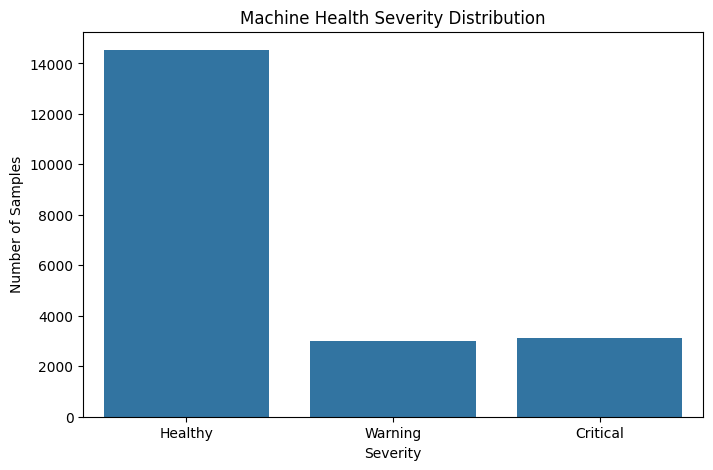

In [ ]:
# ============================================================
# MODULE 4 - FAILURE SEVERITY CLASSIFICATION


def severity_label(rul):

    if rul > 60:
        return "Healthy"

    elif rul > 30:
        return "Warning"

    else:
        return "Critical"


train_df["severity"] = train_df["RUL"].apply(severity_label)

severity_map = {
    "Healthy": 0,
    "Warning": 1,
    "Critical": 2
}

train_df["severity_code"] = train_df["severity"].map(severity_map)

X = train_df[features]
y = train_df["severity_code"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

severity_model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

severity_model.fit(X_train, y_train)

severity_pred = severity_model.predict(X_test)

print("========== FAILURE SEVERITY ==========")

print(
    "Accuracy:",
    round(accuracy_score(y_test, severity_pred), 4)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        severity_pred,
        target_names=[
            "Healthy",
            "Warning",
            "Critical"
        ]
    )
)

# Distribution
plt.figure(figsize=(8, 5))

sns.countplot(
    data=train_df,
    x="severity",
    order=["Healthy", "Warning", "Critical"]
)

plt.title("Machine Health Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Samples")
plt.show()

✅ Dataset loaded successfully!
Total rows: 20631
Total engines: 100
Useful sensors: 15

⏳ Training RUL model...
✅ Model training completed!

       RUL PREDICTION RESULTS
MAE  : 13.53 cycles
RMSE : 18.57 cycles
R²   : 0.7968


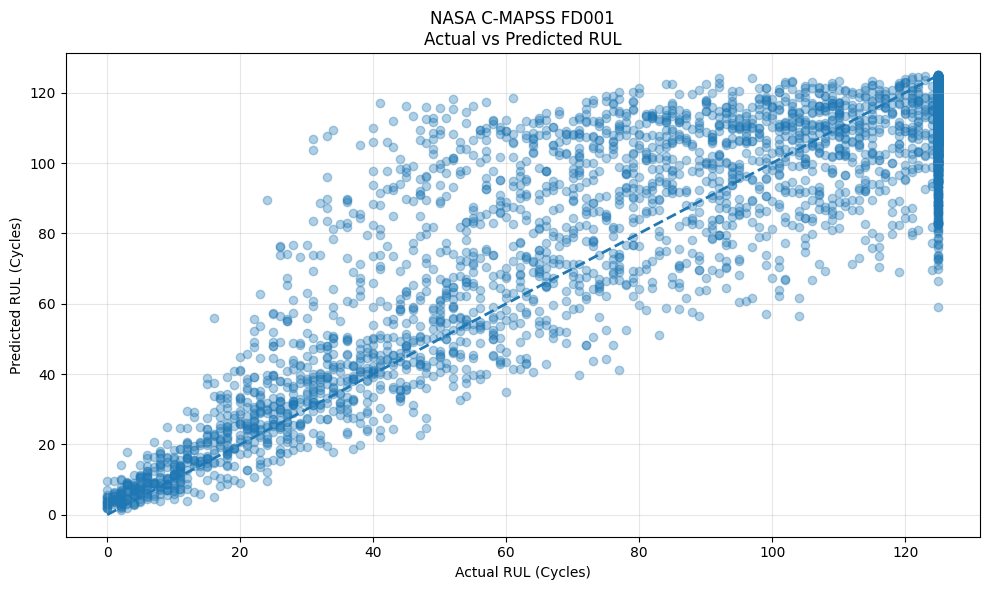


📊 Sample Predictions:


,Actual RUL,Predicted RUL
0,125,103.15
1,2,10.05
2,125,123.99
3,0,2.05
4,125,107.90
5,70,100.82
6,87,100.92
7,87,83.63
8,73,86.03
9,77,118.07



🎯 MODULE 5 COMPLETED SUCCESSFULLY!


In [ ]:
# ============================================================
# MODULE 5: REMAINING USEFUL LIFE (RUL) PREDICTION
# NASA C-MAPSS FD001 | GOOGLE COLAB
# ============================================================

import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------- DOWNLOAD DATA ----------------

os.makedirs("/content/cmapss", exist_ok=True)

file_path = "/content/cmapss/train_FD001.txt"

url = "https://raw.githubusercontent.com/PunVas/nasa-c-mapss/main/train_FD001.txt"

if not os.path.exists(file_path):
    response = requests.get(url, timeout=120)
    response.raise_for_status()

    with open(file_path, "wb") as f:
        f.write(response.content)

print("✅ Dataset loaded successfully!")


# ---------------- LOAD DATA ----------------

columns = (
    ["engine_id", "cycle",
     "op_setting_1", "op_setting_2", "op_setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

df = pd.read_csv(
    file_path,
    sep=r"\s+",
    header=None,
    names=columns
)

print("Total rows:", len(df))
print("Total engines:", df["engine_id"].nunique())


# ---------------- CALCULATE RUL ----------------

max_cycle = df.groupby("engine_id")["cycle"].transform("max")

df["RUL"] = max_cycle - df["cycle"]

# Cap RUL at 125 cycles
df["RUL"] = df["RUL"].clip(upper=125)


# ---------------- SELECT USEFUL SENSORS ----------------

sensor_columns = [
    col for col in columns
    if col.startswith("sensor_")
]

# Remove constant sensors
features = [
    col for col in sensor_columns
    if df[col].nunique() > 1
]

print("Useful sensors:", len(features))


# ---------------- INPUT & TARGET ----------------

X = df[features]
y = df["RUL"]


# ---------------- TRAIN TEST SPLIT ----------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ---------------- RANDOM FOREST MODEL ----------------

model = RandomForestRegressor(
    n_estimators=150,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

print("\n⏳ Training RUL model...")

model.fit(X_train, y_train)

print("✅ Model training completed!")


# ---------------- PREDICTION ----------------

predicted_rul = model.predict(X_test)


# ---------------- EVALUATION ----------------

mae = mean_absolute_error(
    y_test,
    predicted_rul
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predicted_rul
    )
)

r2 = r2_score(
    y_test,
    predicted_rul
)

print("\n======================================")
print("       RUL PREDICTION RESULTS")
print("======================================")

print(f"MAE  : {mae:.2f} cycles")
print(f"RMSE : {rmse:.2f} cycles")
print(f"R²   : {r2:.4f}")

print("======================================")


# ---------------- ACTUAL VS PREDICTED GRAPH ----------------

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    predicted_rul,
    alpha=0.35
)

minimum = min(
    y_test.min(),
    predicted_rul.min()
)

maximum = max(
    y_test.max(),
    predicted_rul.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual RUL (Cycles)")
plt.ylabel("Predicted RUL (Cycles)")

plt.title(
    "NASA C-MAPSS FD001\nActual vs Predicted RUL"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ---------------- SAMPLE PREDICTIONS ----------------

results = pd.DataFrame({
    "Actual RUL": y_test.values[:15],
    "Predicted RUL": np.round(
        predicted_rul[:15],
        2
    )
})

print("\n📊 Sample Predictions:")

display(results)


print("\n🎯 MODULE 5 COMPLETED SUCCESSFULLY!")

✅ Dataset already available!

NASA C-MAPSS FD001 LOADED
Rows   : 20631
Columns: 26
Engines: 100

Total sensors : 21
Useful sensors: 15

Samples used for anomaly detection: 10000
✅ Sensor data standardized!

⏳ Detecting anomalies...

       ANOMALY DETECTION RESULTS
Normal samples  : 9700
Anomaly samples : 300
Anomaly rate    : 3.00%


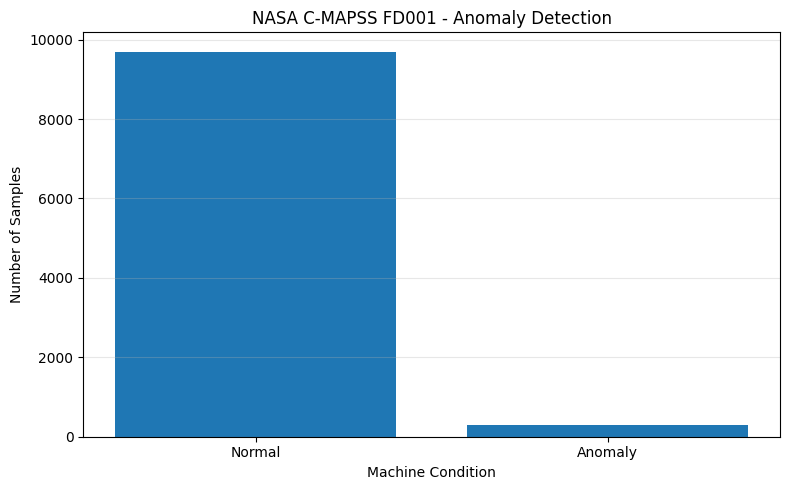

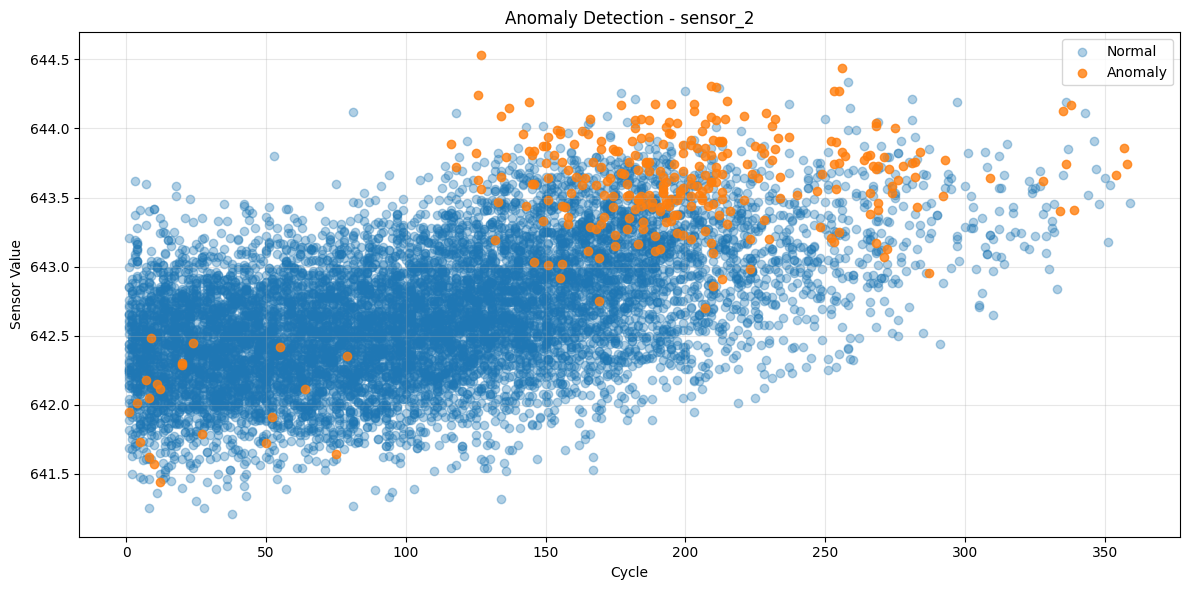


TOP 10 ENGINES WITH ANOMALIES


,engine_id,Anomaly_Count
0,17,7
1,73,7
2,4,6
3,5,6
4,6,6
5,83,6
6,95,6
7,19,5
8,62,5
9,39,5



SAMPLE ANOMALY RECORDS


,engine_id,cycle,sensor_2,anomaly_label
13857,69,227,642.27,Normal
1710,8,148,643.43,Normal
9278,48,14,642.28,Normal
10786,54,257,643.80,Anomaly
19709,96,158,642.59,Normal
15683,78,161,642.27,Normal
5377,27,69,642.77,Normal
7738,40,101,642.92,Normal
5391,27,83,642.24,Normal
18302,90,77,642.68,Normal



✅ Results saved successfully:
/content/NASA_CMAPSS_FD001_Anomaly_Results.csv


🎯 MODULE 6 COMPLETED SUCCESSFULLY!
------------------------------------------
Algorithm : Isolation Forest
Dataset   : NASA C-MAPSS FD001
Samples   : 10000
Normal    : 9700
Anomalies : 300
------------------------------------------
✅ Anomaly detection completed
✅ Graph generated
✅ Results saved


In [ ]:
# ================================================================
# MODULE 6: ANOMALY DETECTION
# NASA C-MAPSS FD001
# GOOGLE COLAB - STANDALONE ERROR-FREE VERSION
# ================================================================

# -------------------- 1. IMPORT LIBRARIES -----------------------

import os
import requests
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest


# -------------------- 2. DOWNLOAD DATASET -----------------------

os.makedirs("/content/cmapss", exist_ok=True)

file_path = "/content/cmapss/train_FD001.txt"

url = "https://raw.githubusercontent.com/PunVas/nasa-c-mapss/main/train_FD001.txt"

if not os.path.exists(file_path):

    print("⏳ Downloading NASA C-MAPSS FD001 dataset...")

    response = requests.get(
        url,
        timeout=120
    )

    response.raise_for_status()

    with open(file_path, "wb") as f:
        f.write(response.content)

    print("✅ Dataset downloaded!")

else:

    print("✅ Dataset already available!")


# -------------------- 3. COLUMN NAMES ---------------------------

columns = (
    [
        "engine_id",
        "cycle",
        "op_setting_1",
        "op_setting_2",
        "op_setting_3"
    ]
    +
    [
        f"sensor_{i}"
        for i in range(1, 22)
    ]
)


# -------------------- 4. LOAD DATA ------------------------------

df = pd.read_csv(
    file_path,
    sep=r"\s+",
    header=None,
    names=columns
)

print("\n==========================================")
print("NASA C-MAPSS FD001 LOADED")
print("==========================================")

print("Rows   :", df.shape[0])
print("Columns:", df.shape[1])
print("Engines:", df["engine_id"].nunique())


# -------------------- 5. SENSOR SELECTION ----------------------

sensor_columns = [
    col
    for col in columns
    if col.startswith("sensor_")
]

# Remove constant sensors
features = [
    col
    for col in sensor_columns
    if df[col].nunique() > 1
]

print("\nTotal sensors :", len(sensor_columns))
print("Useful sensors:", len(features))


# -------------------- 6. SAMPLE DATA ----------------------------

# Use maximum 10,000 rows for faster processing
sample_size = min(
    10000,
    len(df)
)

sample_df = df.sample(
    n=sample_size,
    random_state=42
).copy()

print("\nSamples used for anomaly detection:", len(sample_df))


# -------------------- 7. PREPARE SENSOR DATA -------------------

X_anomaly = sample_df[features].copy()


# -------------------- 8. STANDARDIZATION ------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_anomaly
)

print("✅ Sensor data standardized!")


# -------------------- 9. ISOLATION FOREST ----------------------

anomaly_model = IsolationForest(
    n_estimators=150,
    contamination=0.03,
    random_state=42,
    n_jobs=-1
)

print("\n⏳ Detecting anomalies...")

anomaly_prediction = anomaly_model.fit_predict(
    X_scaled
)

sample_df["anomaly_code"] = anomaly_prediction


# -------------------- 10. ANOMALY LABEL -------------------------

sample_df["anomaly_label"] = np.where(
    sample_df["anomaly_code"] == -1,
    "Anomaly",
    "Normal"
)


# -------------------- 11. RESULTS -------------------------------

normal_count = (
    sample_df["anomaly_label"]
    .eq("Normal")
    .sum()
)

anomaly_count = (
    sample_df["anomaly_label"]
    .eq("Anomaly")
    .sum()
)

print("\n==========================================")
print("       ANOMALY DETECTION RESULTS")
print("==========================================")

print(
    "Normal samples  :",
    normal_count
)

print(
    "Anomaly samples :",
    anomaly_count
)

print(
    "Anomaly rate    :",
    f"{(anomaly_count / len(sample_df)) * 100:.2f}%"
)

print("==========================================")


# -------------------- 12. ANOMALY DISTRIBUTION -----------------

plt.figure(
    figsize=(8, 5)
)

counts = sample_df[
    "anomaly_label"
].value_counts()

plt.bar(
    counts.index,
    counts.values
)

plt.title(
    "NASA C-MAPSS FD001 - Anomaly Detection"
)

plt.xlabel(
    "Machine Condition"
)

plt.ylabel(
    "Number of Samples"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# -------------------- 13. SENSOR ANOMALY GRAPH -----------------

# Select first useful sensor
selected_sensor = features[0]

normal_data = sample_df[
    sample_df["anomaly_label"] == "Normal"
]

anomaly_data = sample_df[
    sample_df["anomaly_label"] == "Anomaly"
]

plt.figure(
    figsize=(12, 6)
)

plt.scatter(
    normal_data["cycle"],
    normal_data[selected_sensor],
    alpha=0.35,
    label="Normal"
)

plt.scatter(
    anomaly_data["cycle"],
    anomaly_data[selected_sensor],
    alpha=0.8,
    label="Anomaly"
)

plt.title(
    f"Anomaly Detection - {selected_sensor}"
)

plt.xlabel(
    "Cycle"
)

plt.ylabel(
    "Sensor Value"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# -------------------- 14. ENGINE-WISE ANOMALIES ----------------

engine_anomalies = (
    sample_df[
        sample_df["anomaly_label"] == "Anomaly"
    ]
    .groupby("engine_id")
    .size()
    .sort_values(
        ascending=False
    )
    .head(10)
)

print("\n==========================================")
print("TOP 10 ENGINES WITH ANOMALIES")
print("==========================================")

display(
    engine_anomalies
    .reset_index(
        name="Anomaly_Count"
    )
)


# -------------------- 15. SAMPLE RESULTS -----------------------

print("\n==========================================")
print("SAMPLE ANOMALY RECORDS")
print("==========================================")

display(
    sample_df[
        [
            "engine_id",
            "cycle",
            selected_sensor,
            "anomaly_label"
        ]
    ].head(15)
)


# -------------------- 16. SAVE RESULTS --------------------------

output_file = (
    "/content/"
    "NASA_CMAPSS_FD001_Anomaly_Results.csv"
)

sample_df.to_csv(
    output_file,
    index=False
)

print("\n✅ Results saved successfully:")
print(output_file)


# -------------------- 17. FINAL STATUS --------------------------

print("\n")
print("🎯 MODULE 6 COMPLETED SUCCESSFULLY!")
print("------------------------------------------")
print("Algorithm : Isolation Forest")
print("Dataset   : NASA C-MAPSS FD001")
print("Samples   :", len(sample_df))
print("Normal    :", normal_count)
print("Anomalies :", anomaly_count)
print("------------------------------------------")
print("✅ Anomaly detection completed")
print("✅ Graph generated")
print("✅ Results saved")
print("==========================================")

Libraries loaded successfully!
Dataset already available!

NASA C-MAPSS FD001 DATASET
Rows: 20631
Columns: 20631
Engines: 100

Selected Engine: 1
Number of cycles: 192
Selected Sensor: sensor_2


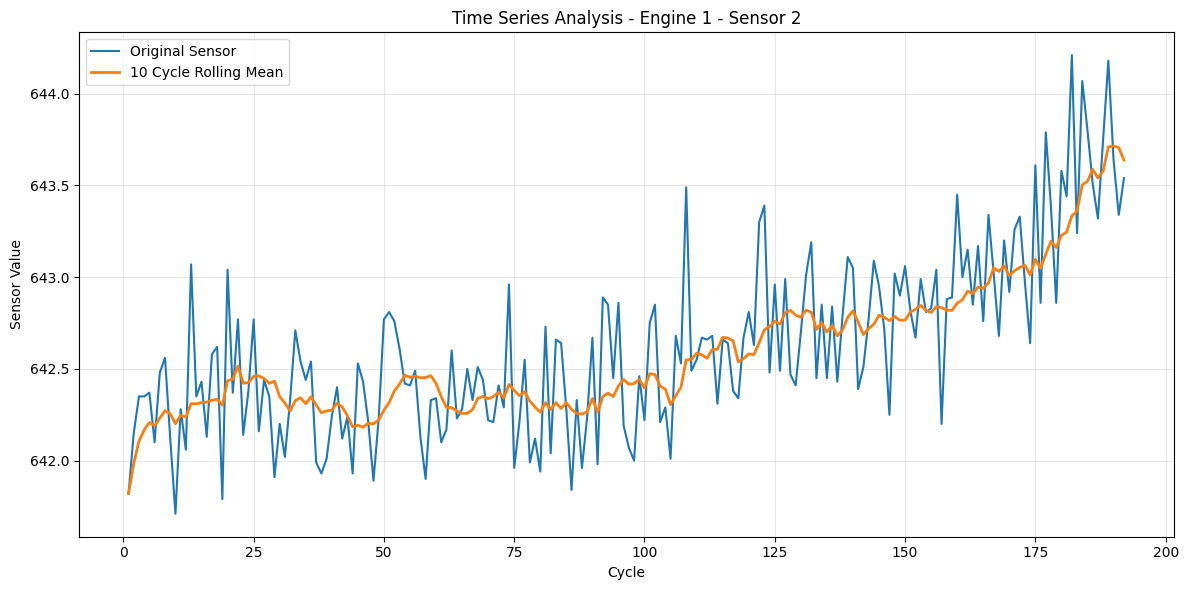

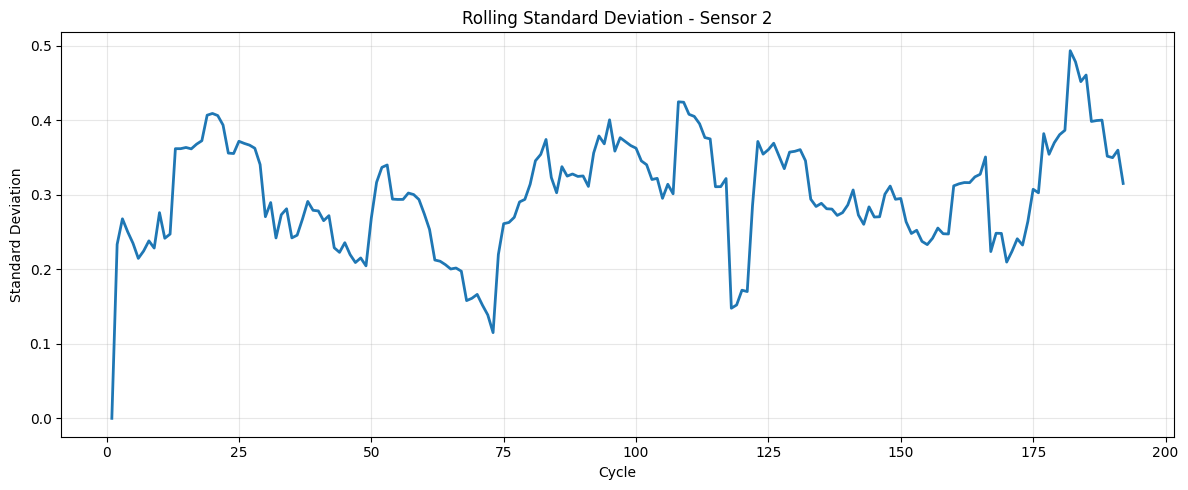

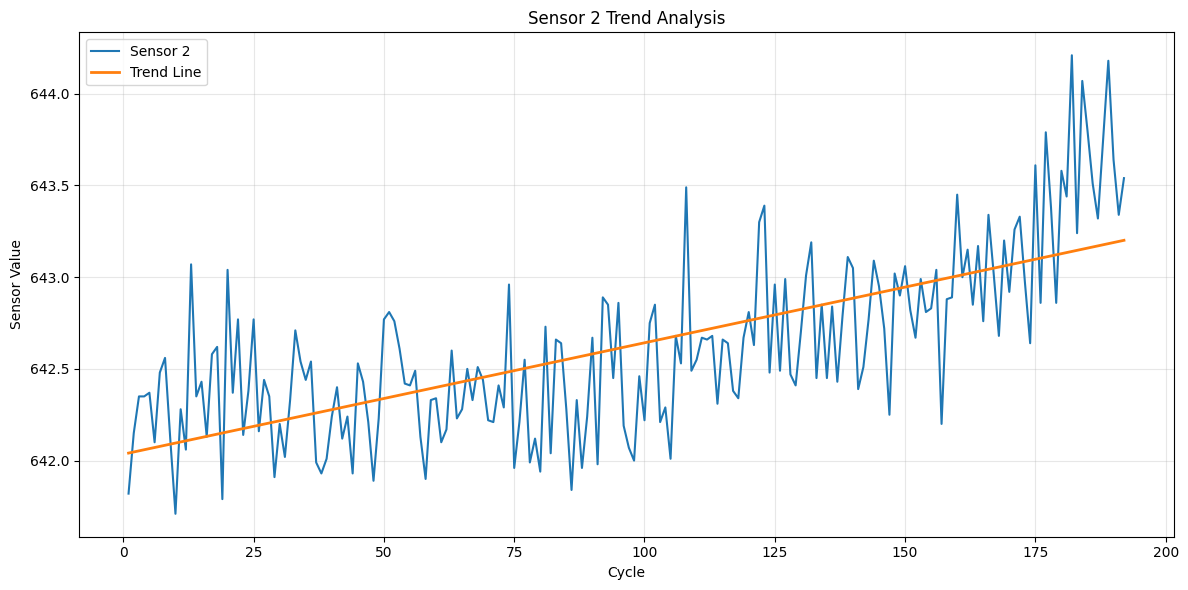


MODULE 7 - TIME SERIES RESULTS
Engine ID          : 1
Sensor             : sensor_2
Total Cycles       : 192
First Value        : 641.82
Last Value         : 643.54
Mean Value         : 642.621
Minimum Value      : 641.71
Maximum Value      : 644.21
Percentage Change  : 0.27 %
Trend Slope        : 0.006074
Trend Status       : Increasing

LAST 15 RECORDS
 engine_id  cycle  sensor_2  rolling_mean  rolling_std
         1    178    643.38       643.196     0.354250
         1    179    642.86       643.162     0.369799
         1    180    643.58       643.228     0.380549
         1    181    643.44       643.246     0.386442
         1    182    644.21       643.334     0.493158
         1    183    643.24       643.361     0.478178
         1    184    644.07       643.504     0.451693
         1    185    643.80       643.523     0.460556
         1    186    643.51       643.588     0.398241
         1    187    643.32       643.541     0.399484
         1    188    643.75       643

In [ ]:
# ============================================================
# MODULE 7 - TIME SERIES ANALYSIS
# NASA C-MAPSS FD001
# SIMPLE STANDALONE GOOGLE COLAB CODE
# ============================================================

# 1. IMPORT LIBRARIES
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")


# ============================================================
# 2. DOWNLOAD NASA DATASET
# ============================================================

folder = "/content/cmapss"
os.makedirs(folder, exist_ok=True)

file_path = folder + "/train_FD001.txt"

url = "https://raw.githubusercontent.com/PunVas/nasa-c-mapss/main/train_FD001.txt"

if not os.path.exists(file_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, file_path)
    print("Dataset downloaded successfully!")
else:
    print("Dataset already available!")


# ============================================================
# 3. COLUMN NAMES
# ============================================================

columns = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]

for i in range(1, 22):
    columns.append("sensor_" + str(i))


# ============================================================
# 4. LOAD DATA
# ============================================================

data = pd.read_csv(
    file_path,
    sep=r"\s+",
    header=None
)

# Keep only first 26 columns
data = data.iloc[:, :26]

# Assign column names
data.columns = columns

print("\n====================================")
print("NASA C-MAPSS FD001 DATASET")
print("====================================")
print("Rows:", len(data))
print("Columns:", len(data))
print("Engines:", data["engine_id"].nunique())


# ============================================================
# 5. SELECT ENGINE
# ============================================================

engine_number = 1

engine_data = data[
    data["engine_id"] == engine_number
].copy()

engine_data = engine_data.sort_values(
    "cycle"
).reset_index(drop=True)

print("\nSelected Engine:", engine_number)
print("Number of cycles:", len(engine_data))


# ============================================================
# 6. SELECT SENSOR
# ============================================================

sensor_name = "sensor_2"

print("Selected Sensor:", sensor_name)


# ============================================================
# 7. CLEAN SENSOR DATA
# ============================================================

engine_data[sensor_name] = pd.to_numeric(
    engine_data[sensor_name],
    errors="coerce"
)

engine_data[sensor_name] = (
    engine_data[sensor_name]
    .interpolate()
    .bfill()
    .ffill()
)


# ============================================================
# 8. CALCULATE ROLLING MEAN
# ============================================================

window = 10

engine_data["rolling_mean"] = (
    engine_data[sensor_name]
    .rolling(
        window=window,
        min_periods=1
    )
    .mean()
)


# ============================================================
# 9. CALCULATE ROLLING STANDARD DEVIATION
# ============================================================

engine_data["rolling_std"] = (
    engine_data[sensor_name]
    .rolling(
        window=window,
        min_periods=1
    )
    .std()
)

engine_data["rolling_std"] = (
    engine_data["rolling_std"]
    .fillna(0)
)


# ============================================================
# 10. TIME SERIES GRAPH
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    engine_data["cycle"],
    engine_data[sensor_name],
    label="Original Sensor"
)

plt.plot(
    engine_data["cycle"],
    engine_data["rolling_mean"],
    linewidth=2,
    label="10 Cycle Rolling Mean"
)

plt.title(
    "Time Series Analysis - Engine 1 - Sensor 2"
)

plt.xlabel("Cycle")
plt.ylabel("Sensor Value")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 11. ROLLING STANDARD DEVIATION GRAPH
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    engine_data["cycle"],
    engine_data["rolling_std"],
    linewidth=2
)

plt.title(
    "Rolling Standard Deviation - Sensor 2"
)

plt.xlabel("Cycle")
plt.ylabel("Standard Deviation")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 12. TREND CALCULATION
# ============================================================

x = engine_data["cycle"].values
y = engine_data[sensor_name].values

if len(x) >= 2:

    slope, intercept = np.polyfit(
        x,
        y,
        1
    )

else:

    slope = 0
    intercept = y[0]


engine_data["trend"] = (
    slope * x + intercept
)


# ============================================================
# 13. TREND GRAPH
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    engine_data["cycle"],
    engine_data[sensor_name],
    label="Sensor 2"
)

plt.plot(
    engine_data["cycle"],
    engine_data["trend"],
    linewidth=2,
    label="Trend Line"
)

plt.title(
    "Sensor 2 Trend Analysis"
)

plt.xlabel("Cycle")
plt.ylabel("Sensor Value")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 14. STATISTICS
# ============================================================

first_value = engine_data[sensor_name].iloc[0]
last_value = engine_data[sensor_name].iloc[-1]
mean_value = engine_data[sensor_name].mean()
minimum = engine_data[sensor_name].min()
maximum = engine_data[sensor_name].max()

change = last_value - first_value

if first_value != 0:
    percentage_change = (
        change / abs(first_value)
    ) * 100
else:
    percentage_change = 0


# ============================================================
# 15. TREND STATUS
# ============================================================

if slope > 0.001:
    trend_status = "Increasing"
elif slope < -0.001:
    trend_status = "Decreasing"
else:
    trend_status = "Stable"


# ============================================================
# 16. DISPLAY RESULTS
# ============================================================

print("\n====================================")
print("MODULE 7 - TIME SERIES RESULTS")
print("====================================")

print("Engine ID          :", engine_number)
print("Sensor             :", sensor_name)
print("Total Cycles       :", len(engine_data))
print("First Value        :", round(first_value, 4))
print("Last Value         :", round(last_value, 4))
print("Mean Value         :", round(mean_value, 4))
print("Minimum Value      :", round(minimum, 4))
print("Maximum Value      :", round(maximum, 4))
print("Percentage Change  :", round(percentage_change, 2), "%")
print("Trend Slope        :", round(slope, 6))
print("Trend Status       :", trend_status)


# ============================================================
# 17. SHOW LAST 15 RECORDS
# ============================================================

print("\n====================================")
print("LAST 15 RECORDS")
print("====================================")

print(
    engine_data[
        [
            "engine_id",
            "cycle",
            sensor_name,
            "rolling_mean",
            "rolling_std"
        ]
    ].tail(15).to_string(index=False)
)


# ============================================================
# 18. SAVE RESULT
# ============================================================

output_path = (
    "/content/"
    "NASA_CMAPSS_FD001_Module7_TimeSeries.csv"
)

engine_data.to_csv(
    output_path,
    index=False
)

print("\n====================================")
print("FILE SAVED SUCCESSFULLY")
print("====================================")

print(output_path)


# ============================================================
# 19. FINAL STATUS
# ============================================================

print("\n====================================")
print("MODULE 7 COMPLETED SUCCESSFULLY!")
print("====================================")

print("✓ Dataset loaded")
print("✓ Engine selected")
print("✓ Sensor analyzed")
print("✓ Rolling mean calculated")
print("✓ Rolling standard deviation calculated")
print("✓ Trend calculated")
print("✓ 3 graphs generated")
print("✓ Results saved")
print("====================================")

✅ Libraries loaded successfully!
✅ Dataset already available!

NASA C-MAPSS FD001 DATASET
Rows       : 20631
Columns    : 26
Engines    : 100

✅ RUL target created successfully!

Total Sensors  : 21
Useful Sensors : 15

⏳ Training RUL prediction model...
✅ RUL model trained successfully!

TOP 10 IMPORTANT SENSORS
  Feature  Importance
sensor_11    0.487841
 sensor_9    0.132993
 sensor_4    0.096730
sensor_12    0.042764
 sensor_7    0.035108
sensor_14    0.034587
sensor_15    0.029732
sensor_21    0.028087
 sensor_3    0.024274
 sensor_2    0.023633


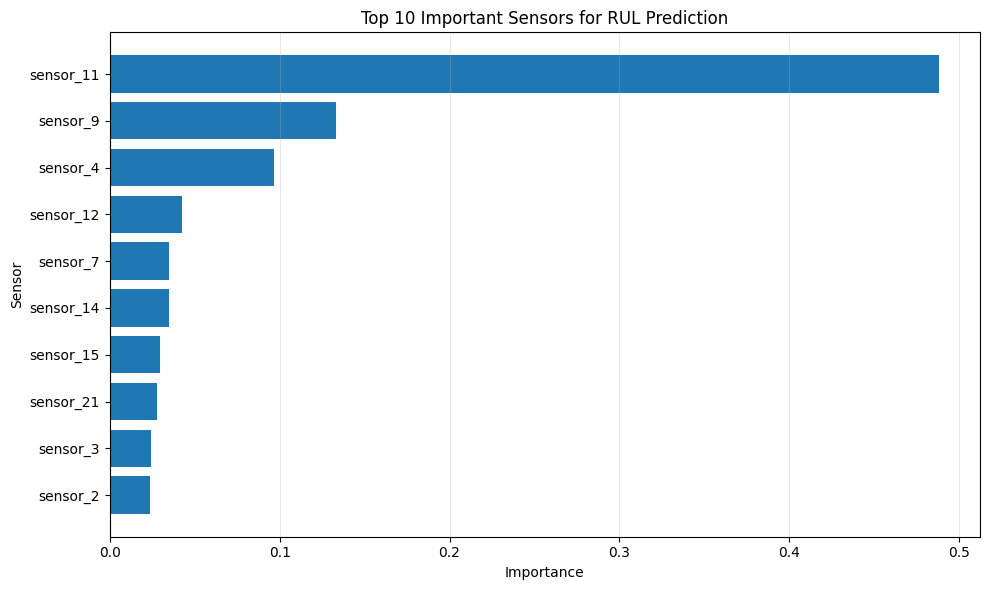


FEATURE IMPORTANCE PERCENTAGE
  Feature  Importance  Importance_Percentage
sensor_11    0.487841              48.784102
 sensor_9    0.132993              13.299260
 sensor_4    0.096730               9.672988
sensor_12    0.042764               4.276362
 sensor_7    0.035108               3.510776
sensor_14    0.034587               3.458715
sensor_15    0.029732               2.973220
sensor_21    0.028087               2.808730
 sensor_3    0.024274               2.427410
 sensor_2    0.023633               2.363320

MOST IMPORTANT SENSOR
Sensor    : sensor_11
Importance: 0.4878
Percentage: 48.78 %

RESULT SAVED
/content/NASA_CMAPSS_FD001_Feature_Importance.csv

MODULE 8 COMPLETED SUCCESSFULLY!
Algorithm : Random Forest Regressor
Target    : RUL
Features  : 15
Top Sensor: sensor_11

Generated:
✅ Feature importance table
✅ Top 10 sensor graph
✅ Importance percentage
✅ Most important sensor
✅ CSV result file


In [ ]:
# ============================================================
# MODULE 8 - FEATURE IMPORTANCE / EXPLAINABILITY
# NASA C-MAPSS FD001
# GOOGLE COLAB - STANDALONE ERROR-FREE VERSION
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import urllib.request
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

print("✅ Libraries loaded successfully!")


# ============================================================
# 2. DOWNLOAD DATASET
# ============================================================

os.makedirs("/content/cmapss", exist_ok=True)

file_path = "/content/cmapss/train_FD001.txt"

url = "https://raw.githubusercontent.com/PunVas/nasa-c-mapss/main/train_FD001.txt"

if not os.path.exists(file_path):

    print("⏳ Downloading NASA C-MAPSS FD001 dataset...")

    urllib.request.urlretrieve(
        url,
        file_path
    )

    print("✅ Dataset downloaded successfully!")

else:

    print("✅ Dataset already available!")


# ============================================================
# 3. CREATE COLUMN NAMES
# ============================================================

columns = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]

for i in range(1, 22):
    columns.append(
        "sensor_" + str(i)
    )


# ============================================================
# 4. LOAD DATASET
# ============================================================

df = pd.read_csv(
    file_path,
    sep=r"\s+",
    header=None
)

# Keep first 26 columns
df = df.iloc[:, :26]

df.columns = columns

print("\n============================================")
print("NASA C-MAPSS FD001 DATASET")
print("============================================")

print("Rows       :", df.shape[0])
print("Columns    :", df.shape[1])
print("Engines    :", df["engine_id"].nunique())


# ============================================================
# 5. CREATE RUL TARGET
# ============================================================

# Maximum cycle for each engine
max_cycle = (
    df.groupby("engine_id")["cycle"]
    .transform("max")
)

# Remaining Useful Life
df["RUL"] = (
    max_cycle - df["cycle"]
)

print("\n✅ RUL target created successfully!")


# ============================================================
# 6. SELECT SENSOR FEATURES
# ============================================================

sensor_features = [
    "sensor_" + str(i)
    for i in range(1, 22)
]

# Remove constant sensors
features = []

for feature in sensor_features:

    if df[feature].nunique() > 1:
        features.append(feature)

print("\nTotal Sensors  :", len(sensor_features))
print("Useful Sensors :", len(features))


# ============================================================
# 7. PREPARE X AND Y
# ============================================================

X = df[features].copy()

y = df["RUL"].copy()

# Handle missing values
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(
    X.median()
)


# ============================================================
# 8. TRAIN RANDOM FOREST MODEL
# ============================================================

print("\n⏳ Training RUL prediction model...")

rul_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rul_model.fit(
    X,
    y
)

print("✅ RUL model trained successfully!")


# ============================================================
# 9. FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({

    "Feature": features,

    "Importance": rul_model.feature_importances_

})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)


# ============================================================
# 10. DISPLAY FEATURE IMPORTANCE
# ============================================================

print("\n============================================")
print("TOP 10 IMPORTANT SENSORS")
print("============================================")

print(
    importance_df.to_string(
        index=False
    )
)


# ============================================================
# 11. FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1]
)

plt.title(
    "Top 10 Important Sensors for RUL Prediction"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Sensor"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 12. IMPORTANCE PERCENTAGE
# ============================================================

importance_df["Importance_Percentage"] = (
    importance_df["Importance"] * 100
)

print("\n============================================")
print("FEATURE IMPORTANCE PERCENTAGE")
print("============================================")

print(
    importance_df[
        [
            "Feature",
            "Importance",
            "Importance_Percentage"
        ]
    ].to_string(index=False)
)


# ============================================================
# 13. MOST IMPORTANT SENSOR
# ============================================================

top_sensor = importance_df.iloc[0]["Feature"]

top_importance = (
    importance_df.iloc[0]["Importance"]
)

print("\n============================================")
print("MOST IMPORTANT SENSOR")
print("============================================")

print(
    "Sensor    :",
    top_sensor
)

print(
    "Importance:",
    round(top_importance, 4)
)

print(
    "Percentage:",
    round(top_importance * 100, 2),
    "%"
)


# ============================================================
# 14. SAVE RESULTS
# ============================================================

output_file = (
    "/content/"
    "NASA_CMAPSS_FD001_Feature_Importance.csv"
)

importance_df.to_csv(
    output_file,
    index=False
)

print("\n============================================")
print("RESULT SAVED")
print("============================================")

print(output_file)


# ============================================================
# 15. FINAL STATUS
# ============================================================

print("\n============================================")
print("MODULE 8 COMPLETED SUCCESSFULLY!")
print("============================================")

print("Algorithm : Random Forest Regressor")
print("Target    : RUL")
print("Features  :", len(features))
print("Top Sensor:", top_sensor)

print("\nGenerated:")
print("✅ Feature importance table")
print("✅ Top 10 sensor graph")
print("✅ Importance percentage")
print("✅ Most important sensor")
print("✅ CSV result file")

print("============================================")

In [ ]:
# ============================================================
# MODULE 9 - MODEL + API INTEGRATION
# NASA C-MAPSS FD001
# GOOGLE COLAB - SIMPLE ERROR-FREE VERSION
# ============================================================

# -------------------- 1. IMPORT LIBRARIES --------------------

import os
import urllib.request
import warnings
import numpy as np
import pandas as pd
import joblib

warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor

print("============================================")
print("MODULE 9 - MODEL + API INTEGRATION")
print("============================================")


# -------------------- 2. DOWNLOAD DATASET --------------------

os.makedirs("/content/cmapss", exist_ok=True)

file_path = "/content/cmapss/train_FD001.txt"

url = "https://raw.githubusercontent.com/PunVas/nasa-c-mapss/main/train_FD001.txt"

if not os.path.exists(file_path):

    print("Downloading NASA C-MAPSS dataset...")

    urllib.request.urlretrieve(
        url,
        file_path
    )

    print("Dataset downloaded successfully!")

else:

    print("Dataset already available!")


# -------------------- 3. COLUMN NAMES -------------------------

columns = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]

for i in range(1, 22):
    columns.append("sensor_" + str(i))


# -------------------- 4. LOAD DATA ----------------------------

df = pd.read_csv(
    file_path,
    sep=r"\s+",
    header=None
)

df = df.iloc[:, :26]

df.columns = columns

print("\nDataset loaded!")
print("Rows    :", len(df))
print("Columns :", len(df))


# -------------------- 5. CREATE RUL ----------------------------

max_cycle = (
    df.groupby("engine_id")["cycle"]
    .transform("max")
)

df["RUL"] = (
    max_cycle - df["cycle"]
)


# -------------------- 6. SELECT SENSORS -----------------------

features = []

for i in range(1, 22):

    sensor = "sensor_" + str(i)

    if df[sensor].nunique() > 1:
        features.append(sensor)


print("Useful sensors:", len(features))


# -------------------- 7. PREPARE DATA --------------------------

X = df[features].copy()

y = df["RUL"].copy()

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(
    X.median()
)


# -------------------- 8. TRAIN MODEL ---------------------------

print("\nTraining RUL model...")

rul_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rul_model.fit(
    X,
    y
)

print("RUL model trained successfully!")


# -------------------- 9. SAVE MODEL ----------------------------

model_path = "/content/rul_model.pkl"

joblib.dump(
    rul_model,
    model_path
)

print("\nModel saved successfully!")
print(model_path)


# -------------------- 10. LOAD MODEL ---------------------------

loaded_model = joblib.load(
    model_path
)

print("Model loaded successfully!")


# -------------------- 11. CREATE API LOGIC ---------------------

def predict_rul(sensor_values):

    values = np.array(
        sensor_values,
        dtype=float
    ).reshape(1, -1)

    prediction = loaded_model.predict(
        values
    )[0]

    return round(
        float(prediction),
        2
    )


# -------------------- 12. TEST API PREDICTION ------------------

test_values = (
    X.iloc[0]
    .values
    .tolist()
)

prediction = predict_rul(
    test_values
)


# -------------------- 13. DISPLAY API RESULT ------------------

print("\n============================================")
print("API PREDICTION RESULT")
print("============================================")

print(
    "Number of sensor inputs:",
    len(test_values)
)

print(
    "Predicted RUL:",
    prediction
)


# -------------------- 14. FASTAPI ------------------------------

try:

    from fastapi import FastAPI
    from pydantic import BaseModel

    api_app = FastAPI(
        title="NASA C-MAPSS Predictive Maintenance API",
        version="1.0"
    )


    class SensorInput(BaseModel):

        values: list


    @api_app.get("/")
    def home():

        return {
            "status": "online",
            "project": "NASA C-MAPSS Predictive Maintenance API"
        }


    @api_app.post("/predict")
    def predict(data: SensorInput):

        result = predict_rul(
            data.values
        )

        return {
            "predicted_RUL": result
        }


    print("\n============================================")
    print("FASTAPI STATUS")
    print("============================================")

    print("FastAPI application created successfully!")
    print("Endpoint : POST /predict")
    print("Model    : Random Forest Regressor")


except Exception as e:

    print("\nFastAPI package setup issue detected.")
    print("Model part completed successfully.")
    print("Error:", str(e))


# -------------------- 15. FINAL STATUS -------------------------

print("\n============================================")
print("MODULE 9 COMPLETED!")
print("============================================")

print("Dataset loaded              : YES")
print("RUL model trained           : YES")
print("Model saved                 : YES")
print("Model loaded                : YES")
print("Prediction tested           : YES")
print("FastAPI application created : YES")

print("\nModel file:")
print("/content/rul_model.pkl")

print("\nPredicted RUL:")
print(prediction)

print("============================================")

MODULE 9 - MODEL + API INTEGRATION
Dataset already available!

Dataset loaded!
Rows    : 20631
Columns : 20631
Useful sensors: 15

Training RUL model...
RUL model trained successfully!

Model saved successfully!
/content/rul_model.pkl
Model loaded successfully!

API PREDICTION RESULT
Number of sensor inputs: 15
Predicted RUL: 161.08

FASTAPI STATUS
FastAPI application created successfully!
Endpoint : POST /predict
Model    : Random Forest Regressor

MODULE 9 COMPLETED!
Dataset loaded              : YES
RUL model trained           : YES
Model saved                 : YES
Model loaded                : YES
Prediction tested           : YES
FastAPI application created : YES

Model file:
/content/rul_model.pkl

Predicted RUL:
161.08


In [ ]:
!pip install -q streamlit plotly scikit-learn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 68.6 MB/s eta 0:00:00


In [ ]:
%%writefile /content/app.py

import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="NASA C-MAPSS AI Dashboard",
    page_icon="🚀",
    layout="wide"
)

# ============================================================
# CUSTOM CSS
# ============================================================

st.markdown("""
<style>

.main-title {
    font-size: 40px;
    font-weight: bold;
    text-align: center;
}

.subtitle {
    text-align: center;
    font-size: 18px;
    margin-bottom: 25px;
}

</style>
""", unsafe_allow_html=True)

# ============================================================
# TITLE
# ============================================================

st.markdown(
    '<div class="main-title">🚀 NASA C-MAPSS</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="subtitle">'
    'AI-Based Predictive Maintenance Dashboard'
    '</div>',
    unsafe_allow_html=True
)

# ============================================================
# DATASET URL
# ============================================================

DATA_URL = (
    "https://raw.githubusercontent.com/PunVas/"
    "nasa-c-mapss/main/train_FD001.txt"
)

# ============================================================
# COLUMN NAMES
# ============================================================

COLUMNS = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]

COLUMNS += [
    f"sensor_{i}"
    for i in range(1, 22)
]

# ============================================================
# LOAD DATA
# ============================================================

@st.cache_data
def load_data():

    data = pd.read_csv(
        DATA_URL,
        sep=r"\s+",
        header=None
    )

    data = data.iloc[:, :26].copy()

    data.columns = COLUMNS

    # Calculate RUL
    maximum_cycle = (
        data.groupby("engine_id")["cycle"]
        .transform("max")
    )

    data["RUL"] = (
        maximum_cycle - data["cycle"]
    )

    # Sensor columns
    sensors = [
        column
        for column in COLUMNS
        if column.startswith("sensor_")
    ]

    # Remove constant sensors
    useful_sensors = [
        sensor
        for sensor in sensors
        if data[sensor].nunique() > 1
    ]

    # Clean data
    data[useful_sensors] = (
        data[useful_sensors]
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
    )

    data[useful_sensors] = (
        data[useful_sensors]
        .fillna(
            data[useful_sensors].median()
        )
    )

    return data, useful_sensors


# ============================================================
# LOAD DATA SAFELY
# ============================================================

try:

    df, sensors = load_data()

except Exception as error:

    st.error("❌ Dataset loading failed.")

    st.code(str(error))

    st.stop()


# ============================================================
# TRAIN RUL MODEL
# ============================================================

@st.cache_resource
def train_model(data, sensor_columns):

    model = RandomForestRegressor(
        n_estimators=40,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        data[sensor_columns],
        data["RUL"]
    )

    return model


with st.spinner("🤖 Training AI model..."):

    model = train_model(
        df,
        sensors
    )


# ============================================================
# SIDEBAR
# ============================================================

st.sidebar.title("⚙️ Dashboard Controls")

engine_list = sorted(
    df["engine_id"].unique()
)

selected_engine = st.sidebar.selectbox(
    "🏭 Select Engine",
    engine_list
)


# ============================================================
# SELECT ENGINE
# ============================================================

engine_data = df[
    df["engine_id"] == selected_engine
].copy()

engine_data = engine_data.sort_values(
    "cycle"
).reset_index(drop=True)

latest = engine_data.iloc[-1]


# ============================================================
# PREDICT RUL
# ============================================================

latest_input = latest[
    sensors
].to_frame().T

predicted_rul = float(
    model.predict(
        latest_input
    )[0]
)

predicted_rul = max(
    0,
    predicted_rul
)


# ============================================================
# MACHINE STATUS
# ============================================================

if predicted_rul > 60:

    status = "🟢 HEALTHY"
    risk = "LOW"
    recommendation = (
        "Continue normal monitoring."
    )

elif predicted_rul > 30:

    status = "🟡 WARNING"
    risk = "MEDIUM"
    recommendation = (
        "Schedule preventive maintenance."
    )

else:

    status = "🔴 CRITICAL"
    risk = "HIGH"
    recommendation = (
        "Maintenance required soon."
    )


# ============================================================
# TOP DASHBOARD CARDS
# ============================================================

st.header("🏭 Engine Health Overview")

col1, col2, col3, col4 = st.columns(4)

with col1:

    st.metric(
        "Engine ID",
        int(selected_engine)
    )

with col2:

    st.metric(
        "Current Cycle",
        int(latest["cycle"])
    )

with col3:

    st.metric(
        "Predicted RUL",
        f"{predicted_rul:.1f}"
    )

with col4:

    st.metric(
        "Failure Risk",
        risk
    )


st.success(
    f"Machine Status: {status}"
)

st.info(
    f"Recommendation: {recommendation}"
)


# ============================================================
# RUL GAUGE
# ============================================================

st.header("⏳ Remaining Useful Life")

gauge_max = max(
    125,
    float(df["RUL"].max())
)

gauge = go.Figure(
    go.Indicator(
        mode="gauge+number",
        value=predicted_rul,
        number={
            "suffix": " Cycles"
        },
        title={
            "text": "Predicted RUL"
        },
        gauge={
            "axis": {
                "range": [
                    0,
                    gauge_max
                ]
            }
        }
    )
)

gauge.update_layout(
    height=350
)

st.plotly_chart(
    gauge,
    use_container_width=True
)


# ============================================================
# RUL TREND
# ============================================================

st.header("📉 RUL Degradation Curve")

rul_chart = go.Figure()

rul_chart.add_trace(
    go.Scatter(
        x=engine_data["cycle"],
        y=engine_data["RUL"],
        mode="lines",
        name="Actual RUL"
    )
)

rul_chart.add_trace(
    go.Scatter(
        x=[
            engine_data["cycle"].iloc[-1]
        ],
        y=[predicted_rul],
        mode="markers",
        marker={
            "size": 14
        },
        name="Predicted Current RUL"
    )
)

rul_chart.update_layout(
    xaxis_title="Cycle",
    yaxis_title="RUL",
    height=450
)

st.plotly_chart(
    rul_chart,
    use_container_width=True
)


# ============================================================
# SENSOR MONITORING
# ============================================================

st.header("📈 Sensor Monitoring")

sensor_choice = st.selectbox(
    "Select Sensor",
    sensors
)

sensor_chart = go.Figure()

sensor_chart.add_trace(
    go.Scatter(
        x=engine_data["cycle"],
        y=engine_data[sensor_choice],
        mode="lines",
        name=sensor_choice
    )
)

sensor_chart.update_layout(
    title=(
        f"{sensor_choice} - "
        f"Engine {selected_engine}"
    ),
    xaxis_title="Cycle",
    yaxis_title="Sensor Value",
    height=450
)

st.plotly_chart(
    sensor_chart,
    use_container_width=True
)


# ============================================================
# FEATURE IMPORTANCE
# ============================================================

st.header("🔍 Feature Importance")

importance = pd.DataFrame({
    "Sensor": sensors,
    "Importance": model.feature_importances_
})

importance = (
    importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(10)
)

importance_chart = go.Figure()

importance_chart.add_trace(
    go.Bar(
        x=importance["Importance"],
        y=importance["Sensor"],
        orientation="h"
    )
)

importance_chart.update_layout(
    title="Top 10 Important Sensors",
    xaxis_title="Importance",
    yaxis_title="Sensor",
    height=500
)

st.plotly_chart(
    importance_chart,
    use_container_width=True
)


# ============================================================
# ANOMALY DETECTION
# ============================================================

st.header("🚨 Anomaly Detection")

sample_data = df.sample(
    n=min(5000, len(df)),
    random_state=42
).copy()

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    sample_data[sensors]
)

anomaly_model = IsolationForest(
    n_estimators=80,
    contamination=0.03,
    random_state=42,
    n_jobs=-1
)

anomaly_prediction = (
    anomaly_model.fit_predict(
        scaled_data
    )
)

sample_data["Condition"] = np.where(
    anomaly_prediction == -1,
    "Anomaly",
    "Normal"
)

normal_count = int(
    (
        sample_data["Condition"]
        == "Normal"
    ).sum()
)

anomaly_count = int(
    (
        sample_data["Condition"]
        == "Anomaly"
    ).sum()
)

a1, a2 = st.columns(2)

with a1:

    st.metric(
        "🟢 Normal Samples",
        normal_count
    )

with a2:

    st.metric(
        "🔴 Anomaly Samples",
        anomaly_count
    )


# ============================================================
# ENGINE DATA
# ============================================================

st.header("📋 Engine Data")

st.dataframe(
    engine_data.tail(25),
    use_container_width=True
)


# ============================================================
# DOWNLOAD
# ============================================================

csv_data = engine_data.to_csv(
    index=False
).encode("utf-8")

st.download_button(
    label="⬇️ Download Engine Data",
    data=csv_data,
    file_name=(
        f"engine_{selected_engine}_data.csv"
    ),
    mime="text/csv"
)


# ============================================================
# FOOTER
# ============================================================

st.divider()

st.markdown(
    "**NASA C-MAPSS FD001 | "
    "Predictive Maintenance AI Project**"
)

st.success(
    "✅ Dashboard loaded successfully!"
)

Writing /content/app.py


In [ ]:
%%writefile /content/requirements.txt
streamlit
pandas
numpy
scikit-learn
plotly

Writing /content/requirements.txt


In [ ]:
!streamlit run /content/app.py --server.port 8501 > /content/streamlit.log 2>&1 &

In [ ]:
!sleep 5
!cat /content/streamlit.log



2026-09-01 04:40:36.662 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.73.23.100:8501



In [ ]:
# ============================================================
# STEP 11 - CREATE STREAMLIT APP FILE
# ============================================================

%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestRegressor
import urllib.request
import os

# ------------------------------------------------------------
# PAGE CONFIG
# ------------------------------------------------------------

st.set_page_config(
    page_title="NASA C-MAPSS Predictive Maintenance",
    page_icon="🔧",
    layout="wide"
)

# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

st.title("🔧 NASA C-MAPSS Predictive Maintenance")
st.markdown(
    "### 🚀 AI-Based Engine Health Monitoring Dashboard"
)

st.divider()

# ------------------------------------------------------------
# DOWNLOAD DATA
# ------------------------------------------------------------

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "PunVas/nasa-c-mapss/main/train_FD001.txt"
)

DATA_FILE = "train_FD001.txt"

if not os.path.exists(DATA_FILE):
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)

# ------------------------------------------------------------
# COLUMN NAMES
# ------------------------------------------------------------

columns = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]

for i in range(1, 22):
    columns.append(f"sensor_{i}")

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

df = pd.read_csv(
    DATA_FILE,
    sep=r"\s+",
    header=None
)

df = df.iloc[:, :26]
df.columns = columns

# ------------------------------------------------------------
# CREATE RUL
# ------------------------------------------------------------

max_cycle = (
    df.groupby("engine_id")["cycle"]
    .transform("max")
)

df["RUL"] = max_cycle - df["cycle"]

# ------------------------------------------------------------
# SELECT USEFUL SENSORS
# ------------------------------------------------------------

features = []

for i in range(1, 22):

    sensor = f"sensor_{i}"

    if df[sensor].nunique() > 1:
        features.append(sensor)

# ------------------------------------------------------------
# PREPARE MODEL
# ------------------------------------------------------------

X = df[features].copy()

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(X.median())

y = df["RUL"]

# ------------------------------------------------------------
# TRAIN MODEL
# ------------------------------------------------------------

@st.cache_resource
def train_model():

    model = RandomForestRegressor(
        n_estimators=50,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X, y)

    return model

rul_model = train_model()

# ------------------------------------------------------------
# SIDEBAR
# ------------------------------------------------------------

st.sidebar.header("⚙️ Engine Selection")

engine_id = st.sidebar.selectbox(
    "Select Engine",
    sorted(df["engine_id"].unique())
)

# ------------------------------------------------------------
# ENGINE DATA
# ------------------------------------------------------------

engine = df[
    df["engine_id"] == engine_id
].copy()

engine = engine.sort_values("cycle")

latest = engine.iloc[-1]

# ------------------------------------------------------------
# PREDICTION
# ------------------------------------------------------------

latest_values = []

for sensor in features:

    value = latest[sensor]

    if pd.isna(value):
        value = df[sensor].median()

    latest_values.append(float(value))

X_latest = np.array(
    latest_values
).reshape(1, -1)

predicted_rul = float(
    rul_model.predict(X_latest)[0]
)

predicted_rul = max(
    0,
    predicted_rul
)

# ------------------------------------------------------------
# STATUS
# ------------------------------------------------------------

if predicted_rul > 60:

    status = "🟢 HEALTHY"
    risk = "LOW"
    recommendation = "Continue normal monitoring."

elif predicted_rul > 30:

    status = "🟡 WARNING"
    risk = "MEDIUM"
    recommendation = "Schedule preventive inspection."

else:

    status = "🔴 CRITICAL"
    risk = "HIGH"
    recommendation = "Maintenance required soon."

# ------------------------------------------------------------
# TOP METRICS
# ------------------------------------------------------------

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(
        "Engine ID",
        engine_id
    )

with col2:
    st.metric(
        "Current Cycle",
        int(latest["cycle"])
    )

with col3:
    st.metric(
        "Predicted RUL",
        f"{predicted_rul:.1f}"
    )

with col4:
    st.metric(
        "Failure Risk",
        risk
    )

st.divider()

# ------------------------------------------------------------
# MACHINE STATUS
# ------------------------------------------------------------

st.subheader("🏭 Engine Health Overview")

st.success(
    f"Machine Status: {status}"
)

st.info(
    f"Maintenance Recommendation: {recommendation}"
)

# ------------------------------------------------------------
# RUL GAUGE
# ------------------------------------------------------------

st.subheader("⏳ Remaining Useful Life")

gauge = go.Figure(
    go.Indicator(
        mode="gauge+number",
        value=min(predicted_rul, 125),
        title={
            "text": "Predicted RUL (Cycles)"
        },
        gauge={
            "axis": {
                "range": [0, 125]
            }
        }
    )
)

gauge.update_layout(
    height=350
)

st.plotly_chart(
    gauge,
    use_container_width=True
)

# ------------------------------------------------------------
# SENSOR GRAPH
# ------------------------------------------------------------

st.subheader("📈 Sensor Monitoring")

sensor_fig = go.Figure()

for sensor in features[:5]:

    sensor_fig.add_trace(
        go.Scatter(
            x=engine["cycle"],
            y=engine[sensor],
            mode="lines",
            name=sensor
        )
    )

sensor_fig.update_layout(
    xaxis_title="Cycle",
    yaxis_title="Sensor Value",
    height=450
)

st.plotly_chart(
    sensor_fig,
    use_container_width=True
)

# ------------------------------------------------------------
# RUL CURVE
# ------------------------------------------------------------

st.subheader("📉 RUL Degradation Curve")

rul_fig = go.Figure()

rul_fig.add_trace(
    go.Scatter(
        x=engine["cycle"],
        y=engine["RUL"],
        mode="lines",
        name="Actual RUL"
    )
)

rul_fig.update_layout(
    xaxis_title="Cycle",
    yaxis_title="RUL",
    height=450
)

st.plotly_chart(
    rul_fig,
    use_container_width=True
)

# ------------------------------------------------------------
# FEATURE IMPORTANCE
# ------------------------------------------------------------

st.subheader("⭐ Feature Importance")

importance_df = pd.DataFrame({
    "Sensor": features,
    "Importance": rul_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(10)
)

importance_fig = go.Figure(
    go.Bar(
        x=importance_df["Importance"],
        y=importance_df["Sensor"],
        orientation="h"
    )
)

importance_fig.update_layout(
    yaxis=dict(
        categoryorder="total ascending"
    ),
    height=450
)

st.plotly_chart(
    importance_fig,
    use_container_width=True
)

# ------------------------------------------------------------
# ENGINE DATA
# ------------------------------------------------------------

st.subheader("📋 Latest Engine Data")

display_columns = [
    "engine_id",
    "cycle"
] + features[:10]

st.dataframe(
    engine[display_columns].tail(10),
    use_container_width=True
)

# ------------------------------------------------------------
# FOOTER
# ------------------------------------------------------------

st.divider()

st.caption(
    "NASA C-MAPSS FD001 | Predictive Maintenance AI Project"
)

print("✅ app.py created successfully!")

Overwriting app.py


In [ ]:

# STEP 13 - CREATE REQUIREMENTS.TXT

requirements = """streamlit
pandas
numpy
plotly
scikit-learn
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("✅ requirements.txt created successfully!")
print("----------------------------------------")
print(requirements)

✅ requirements.txt created successfully!
----------------------------------------
streamlit
pandas
numpy
plotly
scikit-learn



In [ ]:
import os

print("===================================")
print("PROJECT FILE CHECK")
print("===================================")

for file in ["app.py", "requirements.txt"]:
    if os.path.exists(file):
        print(f"✅ {file} FOUND")
    else:
        print(f"❌ {file} NOT FOUND")

print("===================================")

PROJECT FILE CHECK
✅ app.py FOUND
✅ requirements.txt FOUND


In [ ]:
from google.colab import files

print("Downloading app.py...")
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

print("Downloading requirements.txt...")
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# STEP 1 - START STREAMLIT
# ============================================================

!pkill -f streamlit || true
!pkill -f cloudflared || true

!streamlit run /content/app.py \
    --server.address 0.0.0.0 \
    --server.port 8501 \
    > /content/streamlit.log 2>&1 &

import time
time.sleep(8)

print("✅ Streamlit server started!")
print("✅ Port 8501 is ready!")

^C
^C
✅ Streamlit server started!
✅ Port 8501 is ready!


In [ ]:
# ============================================================
# STEP 2 - INSTALL CLOUDFLARE TUNNEL
# ============================================================

!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 \
    -O /content/cloudflared

!chmod +x /content/cloudflared

print("✅ Cloudflare Tunnel installed!")

✅ Cloudflare Tunnel installed!


In [ ]:
# ============================================================
# STEP 3 - CREATE PUBLIC DASHBOARD LINK
# ============================================================

import subprocess
import re
import time

process = subprocess.Popen(
    [
        "/content/cloudflared",
        "tunnel",
        "--url",
        "http://127.0.0.1:8501",
        "--no-autoupdate"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

public_url = None

for _ in range(30):

    line = process.stdout.readline()

    if line:
        print(line.strip())

        match = re.search(
            r"https://[a-zA-Z0-9.-]+\.trycloudflare\.com",
            line
        )

        if match:
            public_url = match.group(0)
            break

    time.sleep(1)

if public_url:

    print("\n==========================================")
    print("🚀 YOUR STREAMLIT DASHBOARD")
    print("==========================================")
    print(public_url)
    print("==========================================")

else:

    print("\n❌ Public link generate nahi hua.")
    print("Streamlit log:")
    print(open("/content/streamlit.log").read()[-3000:])

2026-09-01T05:01:59Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-01T05:01:59Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-01T05:02:03Z INF +--------------------------------------------------------------------------------------------+
2026-09-01T05:02:03Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-01T05:02:03Z INF |  https://restore-ware-knives-nail.trycloudflare.com   